# 08 -- Cold-start Random Forest

Мы решаем cold-start режим -- прогноз нужен сразу после появления ТС, когда длинной истории движения еще нет.

Я обучаю два легких леса:

- `cold_plus_dev` -- текущий snapshot + расписание + геометрия + `cur_dev_s`;
- `cold_strict` -- то же самое, но без `cur_dev_s`.

Длинные rolling-окна `1--30 min`, PCA и признаки, завязанные на историю конкретного ТС, здесь не использую.

В online сервисе логика простая:

```text
cur_dev_s есть      -> cold_plus_dev
cur_dev_s нет       -> cold_strict
история накопилась  -> основной CatBoost
```

Подбор параметров умеренный -- лес обучаю достаточно серьезно, но без чрезмерно долгого поиска. Optuna подбирает основные параметры, а сами деревья параллелятся по всем доступным CPU.

In [22]:
from pathlib import Path
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder

COLD_SEED = 143
COLD_FOLDS = 5
COLD_PURGE_MINUTES = 45

COLD_TRIALS = 24
COLD_TUNE_ESTIMATORS = 350
COLD_EVAL_ESTIMATORS = 800
COLD_FINAL_ESTIMATORS = 1200

COLD_TREE_COUNTS = [100, 250, 500, 800, 1200]

COLD_SYNTHETIC_WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0]
COLD_CLIP_Q = [0.0, 0.001, 0.005]

## 1. Данные

Использую признаки из `02_feature_engineering.ipynb`, но беру только те, которые можно построить без накопленной истории конкретного ТС.

Snapshot-признаки используют последнюю доступную на момент `T` точку. Все исходные признаки в `02_` уже построены с учетом `available_time = max(event_time, receive_time)`, поэтому будущая или еще не пришедшая телеметрия сюда не попадает.

In [23]:
cold_features_dir = Path('../dataset/features')

cold_train = pd.read_pickle(cold_features_dir / 'train_features.pkl')
cold_test = pd.read_pickle(cold_features_dir / 'test_features.pkl')
cold_validate = pd.read_pickle(cold_features_dir / 'validate_features.pkl')

pd.Series({
    'train_rows': len(cold_train),
    'test_rows': len(cold_test),
    'validate_rows': len(cold_validate),
    'train_real': (cold_train.tr_id < 9_000_000).sum(),
    'train_synthetic': (cold_train.tr_id >= 9_000_000).sum(),
})

train_rows         4434
test_rows           353
validate_rows       151
train_real         1141
train_synthetic    3293
dtype: int64

### Признаки cold start

Оставляю четыре группы:

- время и структура расписания;
- текущий GPS snapshot;
- физика движения к target;
- простые взаимодействия между задержкой, расстоянием и оставшимся временем.

Не беру `manual_fill`, altitude, `is_hist_data`, GPS-specific поля из конкурсного CSV, длинные rolling-окна и PCA -- их либо нет в текущем online-контракте, либо для них нужна накопленная история.

In [24]:
COLD_BASE_NUMERIC = [
    'horizon_s', 'horizon_min',
    'minute_of_day', 'target_minute_of_day',
    'time_sin', 'time_cos', 'target_time_sin', 'target_time_cos',
    'hour', 'target_hour',

    'stop_lon', 'stop_lat',
    'schedule_pos', 'schedule_rows', 'schedule_progress',
    'planned_gap_prev_s', 'planned_gap_next_s',
    'prev_segment_m', 'next_segment_m',
    'planned_speed_prev_kmh', 'planned_speed_next_kmh',
    'stop_visit_count', 'stop_headway_prev_s', 'stop_headway_next_s',
    'prev_stop_lon', 'prev_stop_lat', 'next_stop_lon', 'next_stop_lat',

    'last_lon_any', 'last_lat_any', 'last_speed_kmh',
    'last_heading_deg', 'last_location_valid',
    'last_receive_lag_s', 'last_speed_outlier',
    'packet_age_s', 'event_age_s', 'receive_age_s',

    'last_valid_lon', 'last_valid_lat',
    'last_valid_speed_kmh', 'last_valid_heading_deg',
    'valid_age_s',

    'distance_to_target_m', 'bearing_to_target_deg',
    'heading_error_deg', 'heading_error_abs_deg', 'heading_alignment',
    'last_heading_sin', 'last_heading_cos',
    'bearing_sin', 'bearing_cos',
    'projected_speed_kmh', 'required_speed_kmh',
    'speed_margin_kmh', 'projected_speed_margin_kmh',
    'speed_to_required_ratio',
    'eta_last_speed_s', 'eta_projected_speed_s',
    'eta_margin_last_speed_s', 'eta_margin_projected_s',
    'distance_prev_stop_m', 'distance_next_stop_m',

    'scheduled_stops_to_target',
    'first_future_stop_lon', 'first_future_stop_lat',
    'scheduled_path_m',
    'future_gap_mean_s', 'future_gap_max_s',
    'distance_to_first_future_stop_m',
    'route_proxy_m', 'route_proxy_required_speed_kmh',
    'straight_to_route_ratio',

    'valid_age_gt_30s', 'valid_age_gt_90s',
    'valid_age_gt_5m', 'packet_age_gt_30s',

    'planned_seconds_per_stop',
    'route_m_per_stop', 'scheduled_stops_per_min',
    'planned_vs_straight_distance_m', 'route_straightness',
    'distance_x_valid_age',

    'distance_to_target_m_sqrt',
    'required_speed_kmh_sqrt',
    'valid_age_s_sqrt',
    'packet_age_s_sqrt',
    'route_proxy_m_sqrt',
    'last_valid_speed_kmh_sq',
    'required_speed_kmh_sq',

    'same_grid_4', 'same_grid_3', 'same_grid_2',
]

COLD_CATEGORICAL = [
    'target_grid_4', 'target_grid_3', 'target_grid_2',
    'current_grid_4', 'current_grid_3', 'current_grid_2',
]

COLD_DEV_NUMERIC = [
    'cur_dev_s', 'cur_dev_abs', 'cur_dev_sign',
    'cur_dev_log', 'cur_dev_sqrt', 'cur_dev_sq',
    'cur_dev_per_min',
    'cur_dev_x_horizon',
    'cur_dev_x_required_speed',
    'cur_dev_x_distance_km',
    'cur_dev_per_stop',
    'cur_dev_per_km',
    'cur_dev_plus_eta_margin',
    'cur_dev_x_hour_sin',
    'cur_dev_x_hour_cos',
]

cold_expected = COLD_BASE_NUMERIC + COLD_CATEGORICAL + COLD_DEV_NUMERIC
cold_missing = [cold_col for cold_col in cold_expected if cold_col not in cold_train.columns]

assert not cold_missing, cold_missing

cold_strict_features = COLD_BASE_NUMERIC + COLD_CATEGORICAL
cold_plus_dev_features = cold_strict_features + COLD_DEV_NUMERIC

pd.Series({
    'cold_strict_features': len(cold_strict_features),
    'cold_plus_dev_features': len(cold_plus_dev_features),
    'categorical': len(COLD_CATEGORICAL),
})

cold_strict_features       99
cold_plus_dev_features    114
categorical                 6
dtype: int64

## 2. Leakage-safe CV

Validation содержит только реальные ТС. Для каждого реального `tr_id` делю временной ряд на пять последовательных блоков.

Вокруг validation удаляю из train точки того же ТС на 45 минут -- это перекрывает максимальную 30-минутную историю полного пайплайна и 15-минутный prediction horizon.

Synthetic можно использовать только в train.

In [25]:
def cold_build_purged_folds(data, n_splits, purge_minutes):
    cold_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    cold_frame['T'] = pd.to_datetime(cold_frame['T'])
    cold_frame['is_synthetic'] = cold_frame.tr_id >= 9_000_000
    cold_frame['cv_fold'] = -1

    for cold_tr_id, cold_idx in cold_frame.loc[
        ~cold_frame.is_synthetic
    ].groupby('tr_id').groups.items():
        cold_ordered = cold_frame.loc[cold_idx].sort_values('T').index.to_numpy()
        for cold_fold, cold_chunk in enumerate(np.array_split(cold_ordered, n_splits)):
            cold_frame.loc[cold_chunk, 'cv_fold'] = cold_fold

    cold_folds = []
    cold_purge = pd.Timedelta(minutes=purge_minutes)

    for cold_fold in range(n_splits):
        cold_valid_mask = (
            (~cold_frame.is_synthetic)
            & (cold_frame.cv_fold == cold_fold)
        )
        cold_train_mask = ~cold_valid_mask

        for cold_tr_id, cold_valid_part in cold_frame.loc[
            cold_valid_mask
        ].groupby('tr_id'):
            cold_left = cold_valid_part['T'].min() - cold_purge
            cold_right = cold_valid_part['T'].max() + cold_purge

            cold_near_valid = (
                (~cold_frame.is_synthetic)
                & (cold_frame.tr_id == cold_tr_id)
                & cold_frame['T'].between(cold_left, cold_right)
            )
            cold_train_mask &= ~cold_near_valid

        cold_folds.append((
            np.flatnonzero(cold_train_mask.to_numpy()),
            np.flatnonzero(cold_valid_mask.to_numpy())
        ))

    return cold_folds

In [26]:
def cold_audit_folds(data, folds, purge_minutes):
    cold_frame = data[['tr_id', 'T']].copy().reset_index(drop=True)
    cold_frame['T'] = pd.to_datetime(cold_frame['T'])
    cold_rows = []

    for cold_fold, (cold_train_idx, cold_valid_idx) in enumerate(folds):
        cold_train_part = cold_frame.iloc[cold_train_idx]
        cold_valid_part = cold_frame.iloc[cold_valid_idx]
        cold_min_gap = np.inf

        for cold_tr_id, cold_group in cold_valid_part.groupby('tr_id'):
            cold_train_times = cold_train_part.loc[
                cold_train_part.tr_id == cold_tr_id,
                'T'
            ]
            if len(cold_train_times) == 0:
                continue

            cold_gap = np.abs(
                cold_train_times.to_numpy()[:, None]
                - cold_group['T'].to_numpy()[None, :]
            ).min()
            cold_min_gap = min(
                cold_min_gap,
                cold_gap / np.timedelta64(1, 'm')
            )

        cold_rows.append({
            'fold': cold_fold,
            'train_rows': len(cold_train_idx),
            'valid_rows': len(cold_valid_idx),
            'valid_tr_ids': cold_valid_part.tr_id.nunique(),
            'min_same_tr_gap_min': cold_min_gap,
        })

    cold_result = pd.DataFrame(cold_rows)
    assert (cold_result.min_same_tr_gap_min >= purge_minutes).all()

    return cold_result

In [27]:
cold_folds = cold_build_purged_folds(
    cold_train,
    COLD_FOLDS,
    COLD_PURGE_MINUTES
)

cold_fold_audit = cold_audit_folds(
    cold_train,
    cold_folds,
    COLD_PURGE_MINUTES
)

cold_fold_audit

,fold,train_rows,valid_rows,valid_tr_ids,min_same_tr_gap_min
0,0,4130,233,13,50.0
1,1,4042,231,13,50.0
2,2,4082,228,13,50.0
3,3,4060,226,13,50.0
4,4,4149,223,13,50.0


## 3. Preprocessing и RF

Числа заполняю медианой с missing indicators. Пространственные grid-категории кодирую ordinal encoder'ом.

Optuna подбирает только основные параметры леса, вес synthetic и небольшой clipping. Search space специально компактный.

In [28]:
def cold_prepare_frame(data, features):
    cold_frame = data[features].copy()

    for cold_col in COLD_CATEGORICAL:
        if cold_col in cold_frame.columns:
            cold_frame[cold_col] = (
                cold_frame[cold_col]
                .astype('string')
                .fillna('__missing__')
                .astype(str)
            )

    return cold_frame

In [29]:
def cold_make_preprocessor(features):
    cold_cat = [
        cold_col for cold_col in COLD_CATEGORICAL
        if cold_col in features
    ]
    cold_num = [
        cold_col for cold_col in features
        if cold_col not in cold_cat
    ]

    return ColumnTransformer([
        (
            'numeric',
            SimpleImputer(strategy='median', add_indicator=True),
            cold_num
        ),
        (
            'categorical',
            OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ),
            cold_cat
        ),
    ])

In [30]:
def cold_sample_weight(data, synthetic_weight):
    return np.where(
        data.tr_id.to_numpy() >= 9_000_000,
        synthetic_weight,
        1.0
    )


def cold_clip_prediction(prediction, y_train, q):
    if q == 0:
        return prediction

    cold_low, cold_high = y_train.quantile([q, 1 - q])
    return np.clip(prediction, cold_low, cold_high)

In [31]:
def cold_suggest_params(trial):
    cold_bootstrap = trial.suggest_categorical(
        'bootstrap',
        [False, True]
    )

    cold_params = {
        'max_depth': trial.suggest_categorical(
            'max_depth',
            [None, 10, 14, 18, 24, 32]
        ),
        'min_samples_leaf': trial.suggest_int(
            'min_samples_leaf',
            1,
            12
        ),
        'min_samples_split': trial.suggest_int(
            'min_samples_split',
            2,
            24
        ),
        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 'log2', 0.35, 0.5, 0.7, 1.0]
        ),
        'bootstrap': cold_bootstrap,
        'synthetic_weight': trial.suggest_categorical(
            'synthetic_weight',
            COLD_SYNTHETIC_WEIGHTS
        ),
        'clip_q': trial.suggest_categorical(
            'clip_q',
            COLD_CLIP_Q
        ),
    }

    cold_params['max_samples'] = (
        trial.suggest_float(
            'max_samples',
            0.65,
            1.0
        )
        if cold_bootstrap
        else None
    )

    return cold_params

In [32]:
def cold_make_model(
    params,
    n_estimators,
    warm_start=False
):
    return RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        min_samples_split=params['min_samples_split'],
        max_features=params['max_features'],
        bootstrap=params['bootstrap'],
        max_samples=params['max_samples'],
        criterion='squared_error',
        n_jobs=-1,
        random_state=COLD_SEED,
        warm_start=warm_start
    )

In [33]:
cold_x_plus_dev = cold_prepare_frame(
    cold_train,
    cold_plus_dev_features
)
cold_y = cold_train.target_delay_s.astype(float)

In [34]:
def cold_objective(trial):
    cold_params = cold_suggest_params(trial)
    cold_scores = []

    for cold_fold, (cold_train_idx, cold_valid_idx) in enumerate(cold_folds):
        cold_train_part = cold_train.iloc[cold_train_idx]
        cold_weights = cold_sample_weight(
            cold_train_part,
            cold_params['synthetic_weight']
        )
        cold_active = cold_weights > 0

        cold_preprocessor = cold_make_preprocessor(
            cold_plus_dev_features
        )
        cold_train_matrix = cold_preprocessor.fit_transform(
            cold_x_plus_dev.iloc[cold_train_idx].loc[cold_active]
        )
        cold_valid_matrix = cold_preprocessor.transform(
            cold_x_plus_dev.iloc[cold_valid_idx]
        )

        cold_model = cold_make_model(
            cold_params,
            COLD_TUNE_ESTIMATORS
        )
        cold_model.fit(
            cold_train_matrix,
            cold_y.iloc[cold_train_idx].loc[cold_active],
            sample_weight=cold_weights[cold_active]
        )

        cold_prediction = cold_model.predict(cold_valid_matrix)
        cold_prediction = cold_clip_prediction(
            cold_prediction,
            cold_y.iloc[cold_train_idx].loc[cold_active],
            cold_params['clip_q']
        )

        cold_scores.append(
            mean_absolute_error(
                cold_y.iloc[cold_valid_idx],
                cold_prediction
            )
        )

        trial.report(np.mean(cold_scores), step=cold_fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(cold_scores))

In [35]:
cold_artifact_dir = Path('../artifacts/models/cold_start_rf')
cold_artifact_dir.mkdir(parents=True, exist_ok=True)

cold_storage = f"sqlite:///{cold_artifact_dir / 'optuna_v2.db'}"

cold_study = optuna.create_study(
    study_name='cold_start_rf_plus_dev_v2',
    storage=cold_storage,
    load_if_exists=True,
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=COLD_SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=6,
        n_warmup_steps=1
    )
)

cold_finished = sum(
    cold_trial.state in {
        optuna.trial.TrialState.COMPLETE,
        optuna.trial.TrialState.PRUNED
    }
    for cold_trial in cold_study.trials
)

cold_remaining = max(0, COLD_TRIALS - cold_finished)

if cold_remaining:
    cold_study.optimize(
        cold_objective,
        n_trials=cold_remaining,
        n_jobs=1,
        show_progress_bar=False
    )

cold_best_params = cold_suggest_params(cold_study.best_trial)

pd.Series({
    'best_cv_mae': cold_study.best_value,
    **cold_best_params,
})

[I 2026-09-27 16:39:23,048] A new study created in RDB with name: cold_start_rf_plus_dev_v2
[I 2026-09-27 16:39:26,107] Trial 0 finished with value: 44.8221974419905 and parameters: {'bootstrap': False, 'max_depth': 18, 'min_samples_leaf': 3, 'min_samples_split': 5, 'max_features': 'sqrt', 'synthetic_weight': 1.0, 'clip_q': 0.001}. Best is trial 0 with value: 44.8221974419905.
[I 2026-09-27 16:39:29,953] Trial 1 finished with value: 56.46031948814775 and parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 15, 'max_features': 0.35, 'synthetic_weight': 0.75, 'clip_q': 0.005, 'max_samples': 0.7289489199158705}. Best is trial 0 with value: 44.8221974419905.
[I 2026-09-27 16:39:31,508] Trial 2 finished with value: 50.905825603027196 and parameters: {'bootstrap': True, 'max_depth': 24, 'min_samples_leaf': 2, 'min_samples_split': 5, 'max_features': 'log2', 'synthetic_weight': 1.0, 'clip_q': 0.005, 'max_samples': 0.89837818971092}. Best is trial 0 with 

best_cv_mae          43.477224
max_depth                   32
min_samples_leaf             1
min_samples_split            3
max_features              sqrt
bootstrap                False
synthetic_weight           0.5
clip_q                   0.005
max_samples               None
dtype: object

## 4. OOF -- с `cur_dev_s` и без него

Гиперпараметры подбираю только один раз на `cold_plus_dev`.

`cold_strict` обучаю с теми же параметрами -- это экономит время и дает честное сравнение цены отсутствующего `cur_dev_s`.

In [36]:
def cold_oof_predict(features, params):
    cold_x = cold_prepare_frame(cold_train, features)
    cold_parts = []
    cold_importances = []

    for cold_fold, (cold_train_idx, cold_valid_idx) in enumerate(cold_folds):
        cold_train_part = cold_train.iloc[cold_train_idx]
        cold_weights = cold_sample_weight(
            cold_train_part,
            params['synthetic_weight']
        )
        cold_active = cold_weights > 0

        cold_preprocessor = cold_make_preprocessor(features)
        cold_train_matrix = cold_preprocessor.fit_transform(
            cold_x.iloc[cold_train_idx].loc[cold_active]
        )
        cold_valid_matrix = cold_preprocessor.transform(
            cold_x.iloc[cold_valid_idx]
        )

        cold_model = cold_make_model(
            params,
            COLD_EVAL_ESTIMATORS
        )
        cold_model.fit(
            cold_train_matrix,
            cold_y.iloc[cold_train_idx].loc[cold_active],
            sample_weight=cold_weights[cold_active]
        )

        cold_prediction = cold_model.predict(cold_valid_matrix)
        cold_prediction = cold_clip_prediction(
            cold_prediction,
            cold_y.iloc[cold_train_idx].loc[cold_active],
            params['clip_q']
        )

        cold_part = cold_train.iloc[cold_valid_idx][
            ['sample_id', 'tr_id', 'T']
        ].copy()
        cold_part['fold'] = cold_fold
        cold_part['target'] = cold_y.iloc[cold_valid_idx].to_numpy()
        cold_part['prediction'] = cold_prediction
        cold_part['abs_error'] = np.abs(
            cold_part.target - cold_part.prediction
        )
        cold_parts.append(cold_part)

        cold_names = cold_preprocessor.get_feature_names_out()
        cold_importances.append(
            pd.Series(
                cold_model.feature_importances_,
                index=cold_names,
                name=cold_fold
            )
        )

    return (
        pd.concat(cold_parts, ignore_index=True),
        pd.concat(cold_importances, axis=1)
    )

In [37]:
cold_plus_dev_oof, cold_plus_dev_importance = cold_oof_predict(
    cold_plus_dev_features,
    cold_best_params
)

cold_strict_oof, cold_strict_importance = cold_oof_predict(
    cold_strict_features,
    cold_best_params
)

cold_baseline_median = np.median(
    cold_train.loc[cold_train.tr_id < 9_000_000, 'target_delay_s']
)

cold_cv_metrics = pd.Series({
    'cold_plus_dev': cold_plus_dev_oof.abs_error.mean(),
    'cold_strict': cold_strict_oof.abs_error.mean(),
    'global_median': mean_absolute_error(
        cold_strict_oof.target,
        np.full(len(cold_strict_oof), cold_baseline_median)
    ),
    'cur_dev_s': mean_absolute_error(
        cold_plus_dev_oof.target,
        cold_train.set_index('sample_id')
        .loc[cold_plus_dev_oof.sample_id, 'cur_dev_s']
        .to_numpy()
    ),
}).sort_values()

cold_cv_metrics

cold_plus_dev    43.495671
cold_strict      45.689763
cur_dev_s        86.837862
global_median    88.647677
dtype: float64

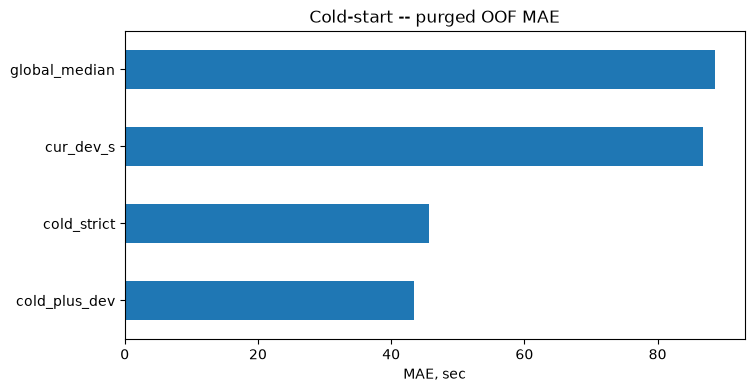

In [38]:
cold_cv_metrics.plot.barh(figsize=(8, 4))
plt.title('Cold-start -- purged OOF MAE')
plt.xlabel('MAE, sec')
plt.show()

In [39]:
cold_importance_summary = pd.DataFrame({
    'mean': cold_plus_dev_importance.mean(axis=1),
    'std': cold_plus_dev_importance.std(axis=1),
}).sort_values('mean', ascending=False)

cold_importance_summary.head(25)

,mean,std
numeric__cur_dev_per_min,0.040464,0.002457
numeric__cur_dev_sqrt,0.034063,0.001072
numeric__cur_dev_s,0.031297,0.001795
numeric__cur_dev_x_horizon,0.029236,0.000785
numeric__cur_dev_log,0.028638,0.000999
numeric__cur_dev_x_required_speed,0.027739,0.000952
numeric__cur_dev_x_distance_km,0.025405,0.001248
numeric__cur_dev_per_stop,0.025207,0.001096
numeric__cur_dev_per_km,0.022150,0.000627
numeric__cur_dev_x_hour_sin,0.022039,0.001368


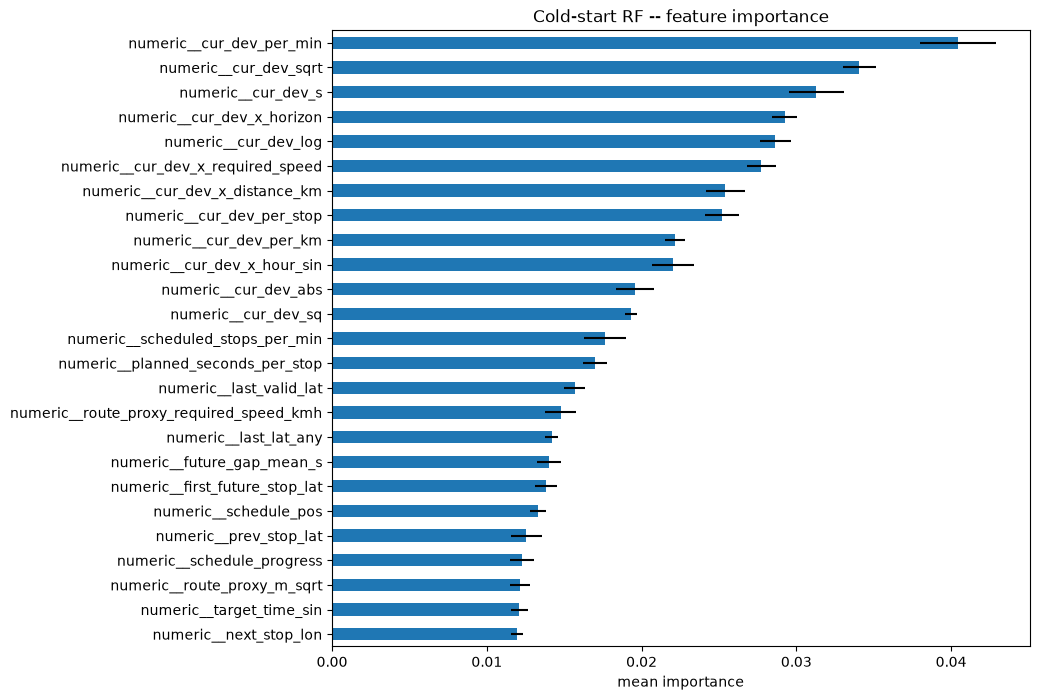

In [40]:
cold_importance_summary.head(25).sort_values('mean').plot.barh(
    y='mean',
    xerr='std',
    figsize=(9, 8),
    legend=False
)
plt.title('Cold-start RF -- feature importance')
plt.xlabel('mean importance')
plt.show()

## 5. Learning curve

Смотрю только `cold_plus_dev` -- это основной cold-start режим, если `cur_dev_s` уже доступен.

Уменьшаю число реальных ТС в train, synthetic оставляю с выбранным весом. Validation остается фиксированной и purged.

In [41]:
def cold_learning_curve(fractions):
    cold_rows = []
    cold_train_idx, cold_valid_idx = cold_folds[-1]

    cold_real_train_ids = (
        cold_train.iloc[cold_train_idx]
        .loc[lambda cold_df: cold_df.tr_id < 9_000_000, 'tr_id']
        .drop_duplicates()
        .to_numpy()
        .copy()
    )

    cold_rng = np.random.default_rng(COLD_SEED)
    cold_rng.shuffle(cold_real_train_ids)

    cold_x = cold_prepare_frame(
        cold_train,
        cold_plus_dev_features
    )

    for cold_fraction in fractions:
        cold_n = max(
            1,
            int(np.ceil(len(cold_real_train_ids) * cold_fraction))
        )
        cold_selected = set(cold_real_train_ids[:cold_n])

        cold_part_idx = np.array([
            cold_idx
            for cold_idx in cold_train_idx
            if (
                cold_train.iloc[cold_idx].tr_id >= 9_000_000
                or cold_train.iloc[cold_idx].tr_id in cold_selected
            )
        ])

        cold_part = cold_train.iloc[cold_part_idx]
        cold_weights = cold_sample_weight(
            cold_part,
            cold_best_params['synthetic_weight']
        )
        cold_active = cold_weights > 0

        cold_preprocessor = cold_make_preprocessor(
            cold_plus_dev_features
        )
        cold_train_matrix = cold_preprocessor.fit_transform(
            cold_x.iloc[cold_part_idx].loc[cold_active]
        )
        cold_valid_matrix = cold_preprocessor.transform(
            cold_x.iloc[cold_valid_idx]
        )

        cold_model = cold_make_model(
            cold_best_params,
            COLD_EVAL_ESTIMATORS
        )
        cold_model.fit(
            cold_train_matrix,
            cold_y.iloc[cold_part_idx].loc[cold_active],
            sample_weight=cold_weights[cold_active]
        )

        cold_prediction = cold_model.predict(cold_valid_matrix)
        cold_prediction = cold_clip_prediction(
            cold_prediction,
            cold_y.iloc[cold_part_idx].loc[cold_active],
            cold_best_params['clip_q']
        )

        cold_rows.append({
            'real_train_tr_ids': cold_n,
            'train_rows': len(cold_part_idx),
            'valid_mae': mean_absolute_error(
                cold_y.iloc[cold_valid_idx],
                cold_prediction
            )
        })

    return pd.DataFrame(cold_rows)

In [42]:
cold_learning = cold_learning_curve(
    [0.25, 0.5, 0.75, 1.0]
)

cold_learning

,real_train_tr_ids,train_rows,valid_mae
0,4,3628,47.543475
1,7,3770,46.992153
2,10,4010,46.477389
3,13,4149,46.832310


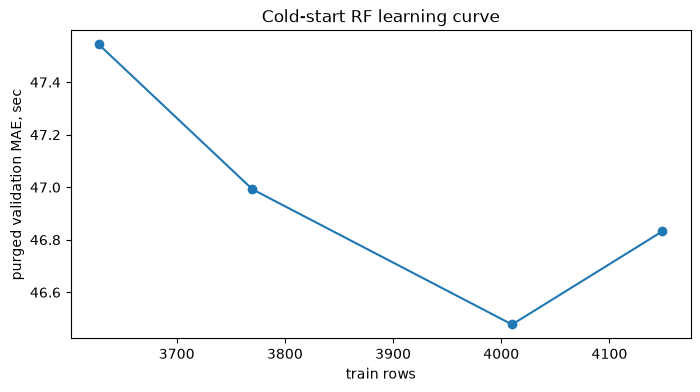

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(
    cold_learning.train_rows,
    cold_learning.valid_mae,
    marker='o'
)
plt.title('Cold-start RF learning curve')
plt.xlabel('train rows')
plt.ylabel('purged validation MAE, sec')
plt.show()

### Сходимость по числу деревьев

Для Random Forest нет эпох в обычном смысле -- ансамбль стабилизируется по мере добавления деревьев.

На последнем purged fold последовательно увеличиваю лес от 100 до 1200 деревьев через `warm_start` и смотрю validation MAE. Если кривая выходит на плато, финального размера леса достаточно.

In [44]:
def cold_tree_convergence(tree_counts):
    cold_train_idx, cold_valid_idx = cold_folds[-1]

    cold_train_part = cold_train.iloc[cold_train_idx]
    cold_weights = cold_sample_weight(
        cold_train_part,
        cold_best_params['synthetic_weight']
    )
    cold_active = cold_weights > 0

    cold_x = cold_prepare_frame(
        cold_train,
        cold_plus_dev_features
    )

    cold_preprocessor = cold_make_preprocessor(
        cold_plus_dev_features
    )
    cold_train_matrix = cold_preprocessor.fit_transform(
        cold_x.iloc[cold_train_idx].loc[cold_active]
    )
    cold_valid_matrix = cold_preprocessor.transform(
        cold_x.iloc[cold_valid_idx]
    )

    cold_model = cold_make_model(
        cold_best_params,
        tree_counts[0],
        warm_start=True
    )

    cold_rows = []

    for cold_n_estimators in tree_counts:
        cold_model.set_params(
            n_estimators=cold_n_estimators
        )
        cold_model.fit(
            cold_train_matrix,
            cold_y.iloc[cold_train_idx].loc[cold_active],
            sample_weight=cold_weights[cold_active]
        )

        cold_prediction = cold_model.predict(
            cold_valid_matrix
        )
        cold_prediction = cold_clip_prediction(
            cold_prediction,
            cold_y.iloc[cold_train_idx].loc[cold_active],
            cold_best_params['clip_q']
        )

        cold_rows.append({
            'n_estimators': cold_n_estimators,
            'valid_mae': mean_absolute_error(
                cold_y.iloc[cold_valid_idx],
                cold_prediction
            )
        })

    return pd.DataFrame(cold_rows)

In [45]:
cold_tree_curve = cold_tree_convergence(
    COLD_TREE_COUNTS
)

cold_tree_curve

,n_estimators,valid_mae
0,100,47.032239
1,250,46.997808
2,500,46.900463
3,800,46.832310
4,1200,46.843895


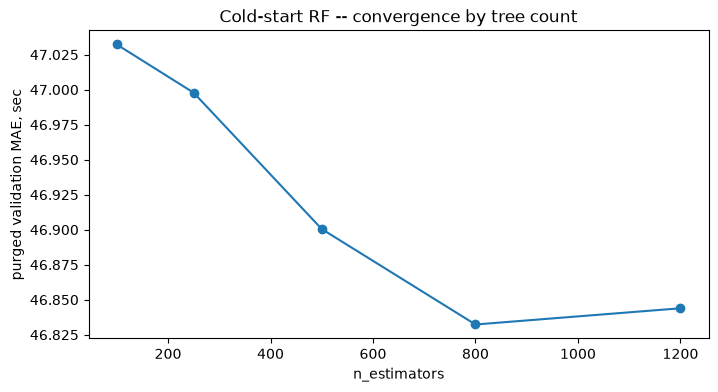

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(
    cold_tree_curve.n_estimators,
    cold_tree_curve.valid_mae,
    marker='o'
)
plt.title('Cold-start RF -- convergence by tree count')
plt.xlabel('n_estimators')
plt.ylabel('purged validation MAE, sec')
plt.show()

Если после 800--1200 деревьев MAE почти не меняется, ансамбль уже стабилизировался. Дальше увеличивать число деревьев имеет мало смысла -- прирост лучше искать в признаках или в более сильной модели.

## 6. Real test

После выбора параметров проверяю оба cold-start режима на полностью real `test`.

In [47]:
def cold_fit_predict(
    train_data,
    train_y,
    eval_data,
    features,
    params,
    n_estimators
):
    cold_train_x = cold_prepare_frame(train_data, features)
    cold_eval_x = cold_prepare_frame(eval_data, features)

    cold_weights = cold_sample_weight(
        train_data,
        params['synthetic_weight']
    )
    cold_active = cold_weights > 0

    cold_preprocessor = cold_make_preprocessor(features)
    cold_train_matrix = cold_preprocessor.fit_transform(
        cold_train_x.loc[cold_active]
    )
    cold_eval_matrix = cold_preprocessor.transform(cold_eval_x)

    cold_model = cold_make_model(params, n_estimators)
    cold_model.fit(
        cold_train_matrix,
        train_y.loc[cold_active],
        sample_weight=cold_weights[cold_active]
    )

    cold_prediction = cold_model.predict(cold_eval_matrix)
    cold_prediction = cold_clip_prediction(
        cold_prediction,
        train_y.loc[cold_active],
        params['clip_q']
    )

    return cold_model, cold_preprocessor, cold_prediction

In [48]:
cold_test_rows = []
cold_test_objects = {}

for cold_name, cold_features in {
    'cold_plus_dev': cold_plus_dev_features,
    'cold_strict': cold_strict_features,
}.items():
    (
        cold_model,
        cold_preprocessor,
        cold_prediction
    ) = cold_fit_predict(
        cold_train,
        cold_train.target_delay_s.astype(float),
        cold_test,
        cold_features,
        cold_best_params,
        COLD_FINAL_ESTIMATORS
    )

    cold_test_objects[cold_name] = (
        cold_model,
        cold_preprocessor,
        cold_features
    )

    cold_test_rows.append({
        'model': cold_name,
        'test_mae': mean_absolute_error(
            cold_test.target_delay_s,
            cold_prediction
        )
    })

cold_test_rows.extend([
    {
        'model': 'cur_dev_s',
        'test_mae': mean_absolute_error(
            cold_test.target_delay_s,
            cold_test.cur_dev_s
        )
    },
    {
        'model': 'global_median',
        'test_mae': mean_absolute_error(
            cold_test.target_delay_s,
            np.full(
                len(cold_test),
                np.median(
                    cold_train.loc[
                        cold_train.tr_id < 9_000_000,
                        'target_delay_s'
                    ]
                )
            )
        )
    },
])

cold_test_metrics = (
    pd.DataFrame(cold_test_rows)
    .sort_values('test_mae')
    .reset_index(drop=True)
)

cold_test_metrics

,model,test_mae
0,cold_plus_dev,46.869428
1,cold_strict,51.051507
2,cur_dev_s,93.359773
3,global_median,101.201133


## 7. Final fit, submission и checkpoints

После real test объединяю `train + test`, fit'ю оба режима и предсказываю hidden `validate`.

Сохраняю модель вместе с fitted preprocessing и списком признаков -- этого достаточно, чтобы потом завернуть cold-start режим в FastAPI.

In [49]:
cold_all = pd.concat(
    [cold_train, cold_test],
    ignore_index=True
)
cold_all_y = cold_all.target_delay_s.astype(float)

cold_submission_template = pd.read_csv(
    '../dataset/sample_submission.csv',
    sep=';'
)

cold_submission_dir = Path('../submissions/cold_start_rf')
cold_submission_dir.mkdir(parents=True, exist_ok=True)

cold_checkpoint_dir = cold_artifact_dir / 'checkpoints'
cold_checkpoint_dir.mkdir(parents=True, exist_ok=True)

cold_final_objects = {}

In [50]:
for cold_name, cold_features in {
    'cold_plus_dev': cold_plus_dev_features,
    'cold_strict': cold_strict_features,
}.items():
    (
        cold_model,
        cold_preprocessor,
        cold_prediction
    ) = cold_fit_predict(
        cold_all,
        cold_all_y,
        cold_validate,
        cold_features,
        cold_best_params,
        COLD_FINAL_ESTIMATORS
    )

    cold_final_objects[cold_name] = {
        'model': cold_model,
        'preprocessor': cold_preprocessor,
        'features': cold_features,
    }

    cold_pred_map = pd.Series(
        cold_prediction,
        index=cold_validate.sample_id
    )

    cold_submission = cold_submission_template.copy()
    cold_submission['prediction'] = cold_submission.sample_id.map(
        cold_pred_map
    )
    cold_submission.to_csv(
        cold_submission_dir / f'{cold_name}.csv',
        sep=';',
        index=False
    )

    cold_checkpoint = {
        'model': cold_model,
        'preprocessor': cold_preprocessor,
        'features': cold_features,
        'params': cold_best_params,
        'seed': COLD_SEED,
        'mode': cold_name,
    }

    with open(
        cold_checkpoint_dir / f'{cold_name}.pkl',
        'wb'
    ) as cold_file:
        pickle.dump(cold_checkpoint, cold_file)

sorted(cold_submission_dir.glob('*.csv'))

[PosixPath('../submissions/cold_start_rf/cold_plus_dev.csv'),
 PosixPath('../submissions/cold_start_rf/cold_strict.csv')]

In [51]:
cold_metadata = {
    'seed': COLD_SEED,
    'purge_minutes': COLD_PURGE_MINUTES,
    'best_cv_mae_plus_dev': float(
        cold_plus_dev_oof.abs_error.mean()
    ),
    'best_cv_mae_strict': float(
        cold_strict_oof.abs_error.mean()
    ),
    'best_params': cold_best_params,
    'service_policy': {
        'cur_dev_available': 'cold_plus_dev',
        'cur_dev_missing': 'cold_strict',
        'enough_history': 'full_catboost',
    },
}

with open(
    cold_artifact_dir / 'metadata.json',
    'w',
    encoding='utf-8'
) as cold_file:
    json.dump(
        cold_metadata,
        cold_file,
        ensure_ascii=False,
        indent=2
    )

cold_plus_dev_oof.to_csv(
    cold_artifact_dir / 'oof_plus_dev.csv',
    index=False
)
cold_strict_oof.to_csv(
    cold_artifact_dir / 'oof_strict.csv',
    index=False
)
cold_test_metrics.to_csv(
    cold_artifact_dir / 'test_metrics.csv',
    index=False
)

cold_artifact_dir

PosixPath('../artifacts/models/cold_start_rf')

## Итоговая production-логика

```python
if enough_history:
    prediction = full_catboost(...)
elif cur_dev_s is not None:
    prediction = cold_plus_dev(...)
else:
    prediction = cold_strict(...)
```

Так cold start закрывается отдельным дешевым сервисным fallback'ом, а уже обученный большой CatBoost остается основной моделью после накопления контекста.

Если времени совсем мало, для интеграции достаточно `cold_plus_dev.pkl`, `cold_strict.pkl` и `metadata.json`.